# Part 1 - Exploratory data analysis

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading into a DataFrame and preprocessing by adding 'count' so that each login is counted as an instance
df = pd.read_json('ultimate_challenge/logins.json')
df['count'] = 1
df.head()

,login_time,count
0,1970-01-01 20:13:18,1
1,1970-01-01 20:16:10,1
2,1970-01-01 20:16:37,1
3,1970-01-01 20:16:36,1
4,1970-01-01 20:26:21,1


In [18]:
df.tail()

,login_time,count
93137,1970-04-13 18:50:19,1
93138,1970-04-13 18:43:56,1
93139,1970-04-13 18:54:02,1
93140,1970-04-13 18:57:38,1
93141,1970-04-13 18:54:23,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
 1   count       93142 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.4 MB


There is no missing data and there are no apparent integrity issues or errors but we note that the final month, April 1970, is incomplete.

Indexing by datetime and aggregating to 15-minute intervals:

In [20]:
df = df.set_index('login_time').sort_index()

# Aggregate to 15-minute intervals
df_15 = df.resample('15min').sum()

Visualizations:

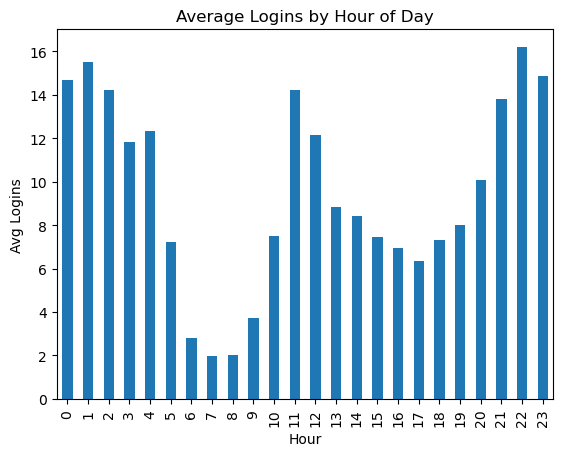

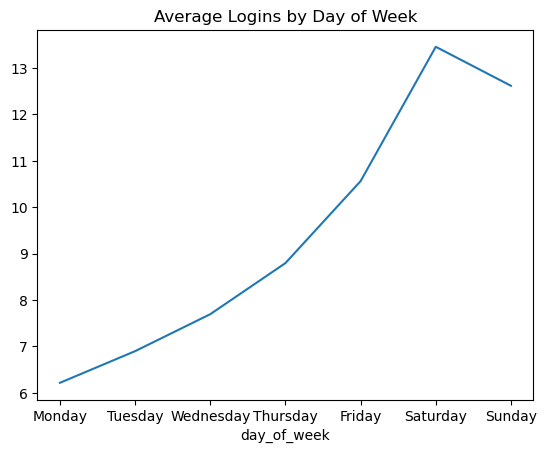

In [21]:
# Visualization: Daily Cycles (Aggregated by hour)
df_15['hour'] = df_15.index.hour
df_15.groupby('hour')['count'].mean().plot(kind='bar')
plt.title('Average Logins by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Logins')
plt.show()

# Visualization: Weekly Patterns
df_15['day_of_week'] = df_15.index.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_15.groupby('day_of_week')['count'].mean().reindex(days).plot(kind='line')
plt.title('Average Logins by Day of Week')
plt.show()

We can see from these graphs that logins peak approximately from 11am until 1pm and from 10pm until 2am and that there is more activity on the weekend days than on weekdays, with the highest average logins on Saturday.

# Part 2 - Experiment and metrics design

1) I would choose the ratio of inter-city trips to total trips per driver. This would be a good metric because it basically adjusts for the total driving volume and other preferences of each driver and avoids the confounding factors that could influence the total logins and total revenue (for each or both cities), such as holidays, changing demographics, and major local events. It is also easy to test in A/B testing to determine the effect of the toll reimbursements on driver behavior.

2) To test the effectiveness of the proposed change, I would recommend a randomized, controlled trial (i.e. an A/B Test). 
    * Implementation: Randomly assign current active drivers into two groups: Group A (a control group) continues paying tolls as usual; Group B receives the toll reimbursements. Record login data for at least a month to capture four full weekly cycles (weekdays vs. weekends). Measure our metric (inner-city trips/total trips) per driver over the duration of the experiment. 

    * Statistical Testing: I would use a two-way z-test to compare the means of the metric between the two groups. We would expect the metric to increase once the toll reimbursements are introduced, so we take as the null hypothesis:
  
      Null Hypothesis (H_0): There is no difference in the mean ratio of inter-city trips to total trips between the two groups A and B.

    * Interpretation & Recommendations: If p < 0.05: We can reject the null hypothesis and conclude that reimbursement significantly increased inter-city mobility as desired. I would recommend a long-term rollout, provided the increased revenue from the extra trips exceeds the cost of reimbursements. The setup should be observed for a longer time to determine if there are any unexpected negative effects on user experience before it is made permanent.

# Part 3 - Predictive modeling